<a href="https://colab.research.google.com/github/hmdaalln/image-denoising-capstone/blob/main/Medium_image_denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Image Denoising

## Project Overview :

In this notebook, we prepare the SIDD dataset and develop a DnCNN model for image denoising.

The workflow includes dataset exploration, data preprocessing, patch generation, model development, training, performance profiling, evaluation, and visualization.

The goal is to train a deep learning model that removes image noise while preserving important visual details such as edges and textures.

## Problem Statement

Image noise can reduce image quality and negatively affect many computer vision applications.

Our objective is to build a model that learns how to transform noisy images into clean images while keeping edges and textures as natural as possible.

## Project Objectives

The main objectives of this project are:

- Explore and understand the SIDD dataset.
- Prepare the dataset for training.
- Train a deep learning model for image denoising.
- Evaluate the model using MSE, PSNR and SSIM.
- Compare the model performance and visualize the results.

## Dataset Description - will update later

This project uses the Smartphone Image Denoising Dataset (SIDD).

The dataset contains pairs of noisy and clean images captured using different smartphones under various lighting conditions. It is specifically designed for image denoising tasks.

## Workflow

1. Import Libraries
2. Explore the Dataset
3. Data Preprocessing
4. Create DataLoaders
5. Build the DnCNN Model
6. Configure the Training Process
7. Profile the Training Pipeline
8. Train and Validate the Model
9. Select the Best Model
10. Evaluate the Model using MSE, PSNR, and SSIM
11. Visualize Denoising Results
12. Save the Final Model

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 1. Import Libraries

In [116]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import copy
import time
import pandas as pd
import random

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.transforms import functional as TF
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
#  Set a fixed random seed for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print ("Random seed:", SEED)

**Why this code?**

A fixed random seed improves the reproducibility of the experiment.

The project contains random operations such as model initialization, training patch selection, and data augmentation. Using the same seed helps make repeated experiments more consistent.

**What did we notice?**

The random seed was set to 42 and will be used throughout the experiment.

## 2. Dataset Exploration

In this section, we explore the SIDD dataset to understand its structure and examine a sample pair of noisy and clean images before training the model.

In [117]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [118]:
# Extract the dataset

zip_path = "/content/drive/MyDrive/Capstone_Project_Medium/mnt2.zip"
extract_path = "/content/SIDD_Medium"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [119]:
# Path to the extracted dataset
dataset_path = "/content/SIDD_Medium/mnt/d/SIDD_Medium_Srgb/Data"

# Get only vaild dataset folders
image_folders = [
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("Number of samples:", len(image_folders))

Number of samples: 189


In [120]:
# Open one sample folder
sample_image = os.path.join(dataset_path, image_folders[2])

# Show the files inside the scene
files = os.listdir(sample_image)

print("Files in the first sample:")
print(files)

Files in the first sample:
['0139_NOISY_SRGB_010.PNG', '0139_NOISY_SRGB_011.PNG', '0139_GT_SRGB_010.PNG', '0139_GT_SRGB_011.PNG']


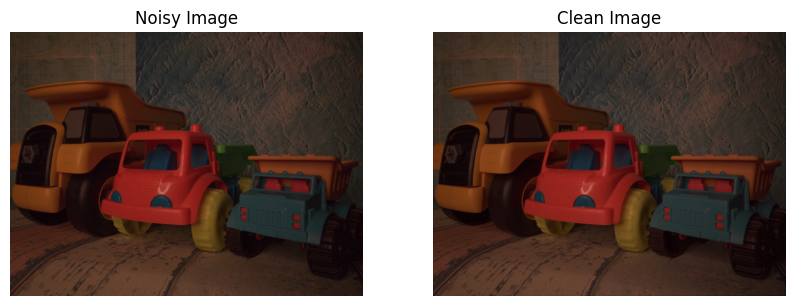

In [121]:
# Read the images
noisy_image = Image.open(os.path.join(sample_image, "0139_NOISY_SRGB_010.PNG"))
clean_image = Image.open(os.path.join(sample_image, "0139_GT_SRGB_010.PNG"))

# Display the images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(noisy_image)
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(clean_image)
plt.title("Clean Image")
plt.axis("off")

plt.show()


### Observation

The SIDD Medium dataset contains multiple noisy and ground-truth images inside each sample folder. Therefore, the image-pairing function must explicitly match each noisy image with the ground-truth image that has the same image index.

For example

- NOISY_SRGB_010 is paired with GT_SRGB_010,
- While NOISY_SRGB_011 is paired with GT_SRGB_011.

This prevents incorrect input-target pairing and allows all available noisy-clean pairs to be used.

## 3. Data Preprocessing
In this section, we prepare the SIDD image pairs for model training.  
First, we split the sample folders into training, validation, and testing sets.  
The images will later be converted into smaller patches and transformed into tensors with pixel values scaled to the [0, 1] range.

##3.1. Split the Dataset

In [122]:
from sklearn.model_selection import train_test_split

# Split the folders into training and remaining data
train_folders, temp_folders = train_test_split(
    image_folders,
    test_size=0.20,
    random_state=42
)

# Split the remaining folders into validation and testing
val_folders, test_folders = train_test_split(
    temp_folders,
    test_size=0.50,
    random_state=42
)

# Check the number of samples in each set
print("Training samples:", len(train_folders))
print("Validation samples:", len(val_folders))
print("Testing samples:", len(test_folders))

Training samples: 151
Validation samples: 19
Testing samples: 19


**Why this code?**

The expanded dataset is divided at the folder level into training, validation, and testing subsets. Splitting at the folder level helps ensure that related images from the same sample folder do not appear in different subsets.

**What did we notice?**

The expanded dataset contains 189 sample folders.

These were divided into:

- 151 training folders
- 19 validation folders
- 19 testing folders

This corresponds to approximately 80% training, 10% validation, and 10% testing.

## 3.2. Precompute the Image Pair Paths

In [123]:
def build_image_pairs(
    dataset_path,
    folders
):

    # Create an empty list to store all noisy-clean pairs
    image_pairs = []

    # Process every sample folder
    for folder in folders:

        # Build the complete sample-folder path
        sample_path = os.path.join(
            dataset_path,
            folder
        )

        # Read and sort the files
        files = sorted(
            os.listdir(sample_path)
        )

        # Find all noisy images
        noisy_files = [
            f for f in files
            if "NOISY_SRGB" in f
        ]

        # Process every noisy image
        for noisy_file in noisy_files:

            # Extract the image index
            # Example:
            # 0003_NOISY_SRGB_010.PNG -> 010
            image_index = (
                noisy_file
                .split("_")[-1]
                .split(".")[0]
            )

            # Find the matching ground-truth image
            matching_gt = [
                f for f in files
                if (
                    "GT_SRGB" in f
                    and
                    f.endswith(
                        f"_{image_index}.PNG"
                    )
                )
            ]

            # Store the pair only if a matching GT exists
            if len(matching_gt) == 1:

                clean_file = matching_gt[0]

                image_pairs.append({
                    "noisy_path": os.path.join(
                        sample_path,
                        noisy_file
                    ),
                    "clean_path": os.path.join(
                        sample_path,
                        clean_file
                    ),
                    "folder": folder,
                    "image_index": image_index
                })

    return image_pairs

**Why this code?**

The SIDD dataset contains multiple noisy and ground-truth images inside each sample folder. Therefore, the image-pairing function must explicitly match each noisy image with the ground-truth image that has the same image index.

For example

- NOISY_SRGB_010 is paired with GT_SRGB_010,
- While NOISY_SRGB_011 is paired with GT_SRGB_011.

This prevents incorrect input-target pairing and allows all available noisy-clean pairs to be used.

**What did we notice?**

The function stores the file paths without loading the images into memory.

Because each sample folder contains multiple image pairs, the function can preserve all matching noisy-clean pairs instead of selecting only one pair per folder.

## 3.3. Create the File Path Lists

In [124]:
# Precompute the noisy-clean image paths
train_pairs = build_image_pairs(
    dataset_path,
    train_folders
)

val_pairs = build_image_pairs(
    dataset_path,
    val_folders
)

test_pairs = build_image_pairs(
    dataset_path,
    test_folders
)

# Check the number of image pairs
print("Training image pairs:", len(train_pairs))
print("Validation image pairs:", len(val_pairs))
print("Testing image pairs:", len(test_pairs))

print("Total image pairs:", len(train_pairs) + len(val_pairs)+ len(test_pairs))

Training image pairs: 262
Validation image pairs: 32
Testing image pairs: 26
Total image pairs: 320


**Why this code?**

This step creates separate noisy-clean image-pair lists for the training, validation, and testing subsets.

Because SIDD folders contain two image pairs while the additional HYNIX folders contain one pair, the number of image pairs is not exactly proportional to the number of folders.

**What did we notice?**

The final path lists contain:

- **262 training pairs**
- **32 validation pairs**
- **26 testing pairs**
- **320 total matched image pairs**

The validation and testing sets contain the same number of folders but slightly different numbers of image pairs because the two dataset sources contribute different numbers of pairs per folder.

## 3.4 Verify Noisy-Clean Image Pair Matching

In [125]:
# Display several noisy-clean pairs
for pair in train_pairs[:10]:

    print(
        "Noisy:",
        os.path.basename(
            pair["noisy_path"]
        )
    )

    print(
        "Clean:",
        os.path.basename(
            pair["clean_path"]
        )
    )

    print(
        "Index:",
        pair["image_index"]
    )

    print("-" * 50)

Noisy: 0190_NOISY_SRGB_010.PNG
Clean: 0190_GT_SRGB_010.PNG
Index: 010
--------------------------------------------------
Noisy: 0190_NOISY_SRGB_011.PNG
Clean: 0190_GT_SRGB_011.PNG
Index: 011
--------------------------------------------------
Noisy: 0099_NOISY_SRGB_010.PNG
Clean: 0099_GT_SRGB_010.PNG
Index: 010
--------------------------------------------------
Noisy: 0099_NOISY_SRGB_011.PNG
Clean: 0099_GT_SRGB_011.PNG
Index: 011
--------------------------------------------------
Noisy: 0150_NOISY_SRGB_010.PNG
Clean: 0150_GT_SRGB_010.PNG
Index: 010
--------------------------------------------------
Noisy: 0150_NOISY_SRGB_011.PNG
Clean: 0150_GT_SRGB_011.PNG
Index: 011
--------------------------------------------------
Noisy: 0044_NOISY_SRGB_010.PNG
Clean: 0044_GT_SRGB_010.PNG
Index: 010
--------------------------------------------------
Noisy: 0044_NOISY_SRGB_011.PNG
Clean: 0044_GT_SRGB_011.PNG
Index: 011
--------------------------------------------------
Noisy: 0129_NOISY_SRGB_010.PNG
C

**Why this code?**

This verification step checks several image pairs before patch generation to confirm that each noisy image is matched with the ground-truth image that has the same sample and image index.

**What did we notice?**

The displayed examples confirm correct matching for both 010 and 011 images. This verifies that the Medium dataset pairing logic is working correctly.

## 3.5. Generate the Image Patches Once

In [126]:
def create_patches(
    image_pairs,
    patch_size,
    patches_per_image,
    training=True
):
    # Create lists to store the generated patches
    noisy_patches = []
    clean_patches = []

    # Process each noisy-clean image pair
    for pair in tqdm(image_pairs):

        # Open the noisy image only once
        noisy_image = Image.open(
            pair["noisy_path"]
        ).convert("RGB")

        # Open the clean image only once
        clean_image = Image.open(
            pair["clean_path"]
        ).convert("RGB")

        # Get image dimensions
        width, height = noisy_image.size

        # Generate several patches from the same loaded image pair
        for patch_index in range(
            patches_per_image
        ):

            # TRAINING: use random crop locations

            if training:

                i, j, h, w = (
                    transforms.RandomCrop.get_params(
                        noisy_image,
                        output_size=(
                            patch_size,
                            patch_size
                        )
                    )
                )

            # VALIDATION / TEST:
            # use deterministic crop locations

            else:

                if patches_per_image == 1:

                    # Use the center of the image
                    i = max(
                        0,
                        (height - patch_size) // 2
                    )

                    j = max(
                        0,
                        (width - patch_size) // 2
                    )

                else:

                    # Spread the fixed patches across the image
                    fraction = (
                        patch_index
                        / (patches_per_image - 1)
                    )

                    i = int(
                        fraction
                        * max(
                            0,
                            height - patch_size
                        )
                    )

                    j = int(
                        fraction
                        * max(
                            0,
                            width - patch_size
                        )
                    )

                h = patch_size
                w = patch_size

            # Crop the same region from the noisy image
            noisy_patch = TF.crop(
                noisy_image,
                i,
                j,
                h,
                w
            )

            # Crop the same region from the clean image
            clean_patch = TF.crop(
                clean_image,
                i,
                j,
                h,
                w
            )


            # Convert the noisy patch to tensor
            noisy_patch = TF.to_tensor(
                noisy_patch
            )

            # Convert the clean patch to tensor
            clean_patch = TF.to_tensor(
                clean_patch
            )

            # Store the generated patches
            noisy_patches.append(
                noisy_patch
            )

            clean_patches.append(
                clean_patch
            )

    # Combine all patches into tensors
    noisy_patches = torch.stack(
        noisy_patches
    )

    clean_patches = torch.stack(
        clean_patches
    )

    return noisy_patches, clean_patches

**Why this code?**

- This is the main optimization.

- The previous dataset class opened a full noisy image and a full clean image every time one patch was requested. Because several patches came from the same image, the same large image files were repeatedly decoded.

The new function:

- opens each noisy/clean pair once,
- creates all required patches while the images are already in memory,
- stores the small patches as tensors,
- prevents repeated PNG decoding during training.

**Why random patches for training?**

Random crops provide different image regions and improve data diversity.

**Why deterministic patches for validation and testing?**

- Validation and test patches should remain the same every time.

- This ensures that changes in validation loss reflect model performance rather than a different random crop.

**What did we notice?**

Training patches are extracted from random spatial locations to expose the model to different image regions.

No geometric data augmentation is applied in the Medium experiment.

Validation and test patches use deterministic crop locations so that evaluation is performed on the same image regions every time.

## 3.6. Generate Training, Validation, and Test Patches

In [127]:
# Generate training patches
train_noisy, train_clean = create_patches(
    train_pairs,
    patch_size=128,
    patches_per_image=4,
    training=True
)

# Generate deterministic validation patches
val_noisy, val_clean = create_patches(
    val_pairs,
    patch_size=128,
    patches_per_image=4,
    training=False
)

# Generate deterministic test patches
test_noisy, test_clean = create_patches(
    test_pairs,
    patch_size=128,
    patches_per_image=4,
    training=False
)

# Display the generated tensor shapes
print("Training noisy patches:", train_noisy.shape)
print("Training clean patches:", train_clean.shape)

print("Validation noisy patches:", val_noisy.shape)
print("Validation clean patches:", val_clean.shape)

print("Testing noisy patches:", test_noisy.shape)
print("Testing clean patches:", test_clean.shape)

  0%|          | 0/262 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

Training noisy patches: torch.Size([1048, 3, 128, 128])
Training clean patches: torch.Size([1048, 3, 128, 128])
Validation noisy patches: torch.Size([128, 3, 128, 128])
Validation clean patches: torch.Size([128, 3, 128, 128])
Testing noisy patches: torch.Size([104, 3, 128, 128])
Testing clean patches: torch.Size([104, 3, 128, 128])


**Why this code?**

This step generates all training, validation, and testing patches before model training begins.

The Medium dataset now uses all matched noisy-clean image pairs. Each training image pair generates four 128 × 128 patches, while each validation and test pair generates four deterministic patches.

The final number of patches is:

- **Training**: 262 × 4 = 1048 patches
- **Validation**: 32 × 4 = 128 patches
- **Testing**: 26 × 4 = 104 patches

**What did we notice?**

Using both image pairs from eachsample folder increased the available training data.



## 3.7. Create the Patch Dataset Class

In [128]:
class PatchDataset(Dataset):

    def __init__(
        self,
        noisy_patches,
        clean_patches
    ):
        # Store the precomputed patches
        self.noisy_patches = noisy_patches
        self.clean_patches = clean_patches

    def __len__(self):

        # Return the total number of patches
        return len(self.noisy_patches)

    def __getitem__(self, index):

        # Get one noisy patch
        noisy = self.noisy_patches[index]

        # Get the matching clean patch
        clean = self.clean_patches[index]

        # Calculate the true residual noise
        noise_target = noisy - clean

        # Return the training sample
        return {
            "noisy": noisy,
            "clean": clean,
            "noise_target": noise_target
        }

**Why this code?**

This dataset class is now very lightweight.

It does not:

- scan folders,
- open PNG files,
- decode full images,
- perform full-image operations.

It simply retrieves already prepared tensors.

**What did we notice?**

- The expensive image loading work is completed before training starts.

- This should reduce DataLoader waiting time.

## 3.8. Create the Dataset Objects

In [129]:
# Create the training dataset
train_dataset = PatchDataset(
    train_noisy,
    train_clean
)

# Create the validation dataset
val_dataset = PatchDataset(
    val_noisy,
    val_clean
)

# Create the testing dataset
test_dataset = PatchDataset(
    test_noisy,
    test_clean
)

# Check dataset sizes
print("Training patches:", len(train_dataset))
print("Validation patches:", len(val_dataset))
print("Testing patches:", len(test_dataset))

Training patches: 1048
Validation patches: 128
Testing patches: 104


**Why this code?**

This step wraps the precomputed noisy and clean patches inside PyTorch Dataset objects so that they can be used by the DataLoaders.

**What did we notice?**

The final datasets contain:

- 1048 training patches
- 128 validation patches
- 104 testing patches

This confirms that all matched SIDD image pairs were included in the patch-generation process.

## 3.9. Check One Sample

In [130]:
# Load one training sample
sample = train_dataset[0]

# Display the tensor shapes
print("Noisy shape:", sample["noisy"].shape)
print("Clean shape:", sample["clean"].shape)
print(
    "Noise target shape:",
    sample["noise_target"].shape
)

Noisy shape: torch.Size([3, 128, 128])
Clean shape: torch.Size([3, 128, 128])
Noise target shape: torch.Size([3, 128, 128])


**Why this code?**

This verifies that the optimized data-preparation pipeline produces the same format expected by DnCNN.

**What did we notice?**

The noisy image, clean image, and noise target all have the shape **[3, 128, 128]**. This confirms that the optimized preprocessing pipeline produces correctly aligned RGB patches for DnCNN.

## 4. Create DataLoaders
In this step, we create DataLoaders for the training, validation, and testing datasets. The DataLoader loads the images in batches during training.

In [131]:
# Create the training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)

# Create the validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)

# Create the test DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)

print("Training patches:", len(train_dataset))
print("Validation patches:", len(val_dataset))
print("Testing patches:", len(test_dataset))

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training patches: 1048
Validation patches: 128
Testing patches: 104
Training batches: 262
Validation batches: 32
Testing batches: 26


**Why this code?**

DataLoaders organize the datasets into batches for efficient model training and evaluation. Training data is shuffled to vary the sample order, while validation and test data remain in a fixed order. Multiple workers, pinned memory, and persistent workers are used to improve data-loading efficiency.

**What did we notice?**

With a batch size of 4:

- 896 training patches produce 224 training batches
- 192 validation patches produce 48 validation batches
- 192 testing patches produce 48 testing batches

In [132]:
# Check one batch

# Load one training batch
batch = next(iter(train_loader))

# Get the three tensors
noisy_batch = batch["noisy"]
clean_batch = batch["clean"]
noise_target_batch = batch[
    "noise_target"
]

# Display the batch shapes
print(
    "Noisy batch:",
    noisy_batch.shape
)

print(
    "Clean batch:",
    clean_batch.shape
)

print(
    "Noise target:",
    noise_target_batch.shape
)

Noisy batch: torch.Size([4, 3, 128, 128])
Clean batch: torch.Size([4, 3, 128, 128])
Noise target: torch.Size([4, 3, 128, 128])


**Why this code?**

This step verifies that the DataLoader returns correctly structured batches before the model is trained.

**What did we notice?**

Each batch has the shape **[4, 3, 128, 128]** for the noisy input, clean target, and noise residual, confirming compatibility with DnCNN.

## 5. Build and Train the DnCNN Model


---

In this section, we build the DnCNN model and prepare it for training.

**DnCNN** uses residual learning. Instead of predicting the clean image directly, the model predicts the noise contained in the image.

The true noise residual is calculated as:

$$
\text{Noise Target}
=
\text{Noisy Image}
-
\text{Clean Image}
$$

The denoised image is calculated as:

$$
\text{Denoised Image}
=
\text{Noisy Image}
-
\text{Predicted Noise}
$$

This approach allows the model to learn the noise present in the image rather than predicting the clean image directly. After the model predicts the noise residual, the denoised image is obtained by subtracting the predicted noise from the noisy input.


## 5.1. Build the DnCNN Architecture

In [133]:
class DnCNN(nn.Module):

    def __init__(
        self,
        image_channels=3,
        depth=17,
        features=128
    ):
        # Initialize the parent PyTorch neural-network class
        super().__init__()

        # Create an empty list that will store all model layers
        layers = []

        # First convolution layer
        layers.append(
            nn.Conv2d(
                in_channels=image_channels,
                out_channels=features,
                kernel_size=3,
                padding=1,
                bias=True
            )
        )

        # Apply the ReLU activation function
        layers.append(nn.ReLU(inplace=True))

        # Middle convolution layers
        for _ in range(depth - 2):

          #Extract deeper image and noise features
            layers.append(
                nn.Conv2d(
                    in_channels=features,
                    out_channels=features,
                    kernel_size=3,
                    padding=1,
                    bias=False
                )
            )

            # Normalize the feature maps to improve training stability
            layers.append(nn.BatchNorm2d(features))

            # Add non-linearity
            layers.append(nn.ReLU(inplace=True))

        # Final convolution layer
        layers.append(
            nn.Conv2d(
                in_channels=features,
                out_channels=image_channels,
                kernel_size=3,
                padding=1,
                bias=True
            )
        )

        # Combine all layers into one sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x):

        # Pass the noisy image through the model
        predicted_noise = self.model(x)

        # Return the predicted noise residual
        return predicted_noise

**Why this code?**

- This code defines the architecture of the DnCNN model.

- The model receives a noisy RGB image and predicts the noise residual contained in the image.

The first convolution layer extracts image features. The middle layers learn more complex noise patterns, and the final convolution layer produces the predicted noise.


**Why do we use residual learning?**

- Residual learning allows the network to focus on estimating the noise component rather than directly reconstructing the full clean image.

- The model focuses on the unwanted information that should be removed while preserving the original image content.

**Step explanation**

- image_channels=3 means the input images are RGB.
- depth=17 creates 17 convolutional layers.
- features=128 means the hidden layers use 128 feature maps.
- kernel_size=3 applies a 3 × 3 filter.
- padding=1 keeps the image height and width unchanged.
- BatchNorm2d helps stabilize training.
- ReLU introduces non-linearity.
- The final layer outputs three channels.

**What did we notice?**

The model accepts a three channel RGB image and produces a three channel predicted noise image.

The final layer does not use ReLU because the noise residual may contain both positive and negative values.

## 5.2. Select the device



In [134]:
# Select the GPU when available; otherwise use the CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Display the selected device
print("Device:", device)

Device: cuda


**Why this code?**

This code checks whether a GPU is available.

A GPU can train the deep learning model faster than a CPU.

**Step explanation**

- torch.cuda.is_available() checks whether CUDA is available.
- If CUDA is available, the device is set to cuda.
- Otherwise, the device is set to cpu.

**What did we notice?**

The output was:

**Device: cuda**

This means the notebook is using a GPU runtime.

The model and image batches must be moved to the same device.

## 5.3. Test the Model with  a Random Tensor

In [135]:
# Create a temporary DnCNN model for architecture testing
test_model = DnCNN()

# Create a random tensor that represents a batch of images
x = torch.randn(
    4,     # Batch size
    3,      # RGB channels
    128,     # Image height
    128      # Image width
)

# Pass the random batch through the model
y = test_model(x)

# Display the input and output shapes
print("Input shape:", x.shape)
print("Output shape:", y.shape)

Input shape: torch.Size([4, 3, 128, 128])
Output shape: torch.Size([4, 3, 128, 128])


**Why this code?**

This code tests the model using a randomly generated tensor before using real images.

It confirms that the model architecture does not contain channel or dimension errors.

**Step explanation**

- 4 is the number of image patches processed together.
- 3 represents the RGB channels.
- 128 × 128 is the patch height and width.
- The random tensor is passed through DnCNN to test the architecture.
- The input and output shapes are printed.

**What did we notice?**

The input and output shapes are both:

**torch.Size([4, 3, 128, 128])**

This confirms that DnCNN predicts a three-channel noise residual with the same spatial dimensions as the input.

## 5.4. Create the DnCNN Model


In [136]:
# Create the DnCNN model
model = DnCNN(
    image_channels=3,
    depth=17,
    features=128
)

# Move the model to the selected device
model = model.to(device)

# Display the complete model architecture
print(model)

DnCNN(
  (model): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): Conv2d(128, 128, kernel_s

**Why this code?**

This cell creates the **DnCNN** model and moves it to the selected device.

**Step explanation**

- image_channels=3: the input images are RGB.
- depth=17: the network contains 17 convolutional layers.
- features=128: the hidden layers use 128 feature maps.
- .to(device) moves the model to the GPU or CPU.

**What did we notice?**

- The first layer converts three RGB channels into 128 feature maps.

- The middle layers process 128 feature maps.

- The final layer converts the 128 feature maps back into a three channel predicted noise image.

## 5.5. Count the Model Parameters

In [137]:
# Count all parameters in the model
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

# Count only the parameters that will be updated during training
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

# Display the parameter counts
print("Total parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)

Total parameters: 2222723
Trainable parameters: 2222723


**Why this code?**

This code calculates the total number of parameters in the model.

The parameter count helps us understand the size and complexity of DnCNN.

**Step explanation**

- model.parameters() accesses the model parameters.
- parameter.numel() counts the values in each parameter tensor.
- requires_grad checks whether the parameter will be updated during training.

**What did we notice?**

The model contains:

- Total parameters: 2222723
- Trainable parameters: 2222723

All model parameters are trainable.

## 5.6. Test the Forward Pass

In [138]:
# Load one batch from the training DataLoader
batch = next(iter(train_loader))

# Get the noisy-image batch
noisy_batch = batch["noisy"]

# Move the batch to the selected device
noisy_batch = noisy_batch.to(device)

# Disable gradient calculations because this is only a test
with torch.no_grad():

    # Predict the noise residual
    predicted_noise = model(noisy_batch)

# Display the input and output shapes
print("Input shape:", noisy_batch.shape)
print("Predicted noise shape:", predicted_noise.shape)

Input shape: torch.Size([4, 3, 128, 128])
Predicted noise shape: torch.Size([4, 3, 128, 128])


**Why this code?**

This code tests the model using a real batch from the training DataLoader.

It confirms that the dataset, DataLoader, model, and device work together correctly.

**Step explanation**

- next(iter(train_loader)) loads one batch.
- batch["noisy"] retrieves the noisy images.
- .to(device) moves the images to the GPU or CPU.
- torch.no_grad() disables gradient calculations.
- The model predicts the noise residual.

**What did we notice?**

The input and predicted noise shapes are:

**torch.Size([4, 3, 128, 128])**

This confirms that the Dataset, DataLoader, selected compute device, and DnCNN model work together correctly.

## Training Setup and Training Loop


---


## 5.7. Define the Training Configuration

In [139]:
# Store the main training settings in one dictionary
CONFIG = {
    "learning_rate": 0.001,
    "epochs": 50,
    "early_stopping_patience": 5
}

**Why this code?**

This dictionary stores the main training settings in one place.

**Step explanation**

- learning_rate controls the size of the model updates.
- epochs defines the maximum number of training cycles.
- early_stopping_patience controls how long training waits when validation loss does not improve.

**What did we notice?**

- The initial learning rate is 0.001.

- The model can train for a maximum of 50 epochs.

- Training may stop early if validation loss does not improve for five consecutive epochs.

## 5.8. Create Output Folders

In [140]:
# Define the main output directory in Google Drive
OUTPUT_ROOT = (
    "/content/drive/MyDrive/"
    "Capstone_Project_Medium/Image_Denoising_Results"
)

# Create the checkpoint folder path
CHECKPOINT_ROOT = os.path.join(
    OUTPUT_ROOT,
    "checkpoints"
)

# Create the metadata folder path
METADATA_ROOT = os.path.join(
    OUTPUT_ROOT,
    "metadata"
)

# Create the results folder path
RESULTS_ROOT = os.path.join(
    OUTPUT_ROOT,
    "results"
)
# Create the folders if it does not exist
os.makedirs(CHECKPOINT_ROOT, exist_ok=True)
os.makedirs(METADATA_ROOT, exist_ok=True)
os.makedirs(RESULTS_ROOT, exist_ok=True)

# Display the folder locations
print("Output folders created successfully.")
print("Checkpoint folder:", CHECKPOINT_ROOT)
print("Metadata folder:", METADATA_ROOT)
print("Results folder:", RESULTS_ROOT)


Output folders created successfully.
Checkpoint folder: /content/drive/MyDrive/Capstone_Project_Medium/Image_Denoising_Results/checkpoints
Metadata folder: /content/drive/MyDrive/Capstone_Project_Medium/Image_Denoising_Results/metadata
Results folder: /content/drive/MyDrive/Capstone_Project_Medium/Image_Denoising_Results/results


**Why this code?**

This code creates folders for saving the model and project results.

The folders are stored in Google Drive so that the files remain available after the Colab session ends.

**Step explanation**

- The checkpoint folder stores trained models.
- The metadata folder stores training history and configuration.
- The results folder stores evaluation results and images.
exist_ok=True prevents an error if the folders already exist.

**What did we notice?**

- All output folders were created successfully inside Google Drive.

- The printed paths confirm where the model and results will be saved.

## 5.9. Define the Loss Function

In [141]:
criterion = nn.MSELoss()

**Why this code?**

The model predicts the noise residual.

MSE loss measures the average squared difference between the predicted noise and the true noise residual.

**Step explanation**

The loss is calculated using:

loss = criterion(
    predicted_noise,
    target_noise
)

A smaller loss means the predicted noise is closer to the true noise.

**What did we notice?**

- The MSE loss function was created successfully.

- No output is displayed because the loss value is calculated only when data is passed to the function.

## 5.10. Define the Optimizer

In [142]:
optimizer = Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"]
)

**Why this code?**

The optimizer updates the model parameters during training.

Adam is commonly used because it provides stable and efficient parameter updates.

**Step explanation**

- model.parameters() gives Adam access to all trainable parameters.
- The learning rate is taken from the configuration dictionary.
- optimizer.step() updates the model after gradients are calculated.

**What did we notice?**

- The Adam optimizer was initialized successfully.

- The initial learning rate is 0.001

## 5.11. Define the Learning Rate Scheduler

In [143]:
# Reduce the learning rate when validation loss stops improving
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

**Why this code?**

The scheduler reduces the learning rate when validation loss stops improving.

A smaller learning rate allows the optimizer to make smaller adjustments during later training stages.

**Step explanation**

- mode="min" means a smaller validation loss is better.
- factor=0.5 reduces the learning rate by half.
- patience=2 waits for two epochs without improvement.
- min_lr=1e-6 sets the minimum learning rate.

**What did we notice?**

- The scheduler was initialized successfully.

- No output is displayed because the scheduler will only change the learning rate after receiving validation-loss values.

## 5.12. Enable Mixed - Precision Training

In [144]:
# Create the gradient scaler for mixed-precision training
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

**Why this code?**

Mixed precision can:

- reduce GPU memory usage,
- speed up convolution operations,
- allow a larger batch size.

**What did we notice?**

The scaler is enabled only when a CUDA GPU is available.

## 5.13. Define the one Epoch Function

In [145]:
def run_epoch(
    model,
    loader,
    training
):

    # Select training or evaluation mode
    if training:
        model.train()
    else:
        model.eval()

    # Store the total loss
    total_loss = 0.0

    # Store the number of processed samples
    total_samples = 0

    # Process every batch
    for batch in tqdm(
        loader,
        leave=False
    ):

        # Get the noisy images
        noisy = batch["noisy"]

        # Move noisy images to the GPU or CPU
        noisy = noisy.to(
            device,
            non_blocking=True
        )

        # Get the true residual noise
        target_noise = batch["noise_target"]

        # Move the target residual to the GPU or CPU
        target_noise = target_noise.to(
            device,
            non_blocking=True
        )


        # Clear previous gradients during training
        if training:
            optimizer.zero_grad(
                set_to_none=True
            )


        # Step 4: Enable gradients only during training
        with torch.set_grad_enabled(training):

            # Use mixed precision when CUDA is available
            with torch.amp.autocast(
                device_type="cuda",
                enabled=torch.cuda.is_available()
            ):

                # Predict the residual noise
                predicted_noise = model(noisy)

                # Calculate the MSE loss
                loss = criterion(
                    predicted_noise,
                    target_noise
                )


            # Update weights only during training
            if training:

                # Scale the loss and calculate gradients
                scaler.scale(loss).backward()

                # Update the model parameters
                scaler.step(optimizer)

                # Update the gradient scaler
                scaler.update()

        # Get the number of samples in this batch
        batch_size = noisy.size(0)

        # Add the weighted batch loss
        total_loss += (
            loss.item() * batch_size
        )

        # Update the processed-sample count
        total_samples += batch_size

    # Calculate the average loss for the full epoch
    average_loss = (
        total_loss / total_samples
    )

    # Return the average epoch loss
    return average_loss

**Why this code?**

This function runs one complete pass through either the training or validation dataset.

It is used for both stages to avoid repeating similar code.

**Step explanation**

- model.train() enables training behavior.

- model.eval() changes the model to evaluation mode.

- optimizer.zero_grad() removes gradients from the previous batch.

- predicted_noise = model(noisy) performs the forward pass.

- scaler.scale(loss).backward() calculates the gradients using gradient scaling during
mixed-precision training.

- scaler.step(optimizer) updates the model parameters.

- scaler.update() adjusts the gradient scaling factor for the next iteration.


**What did we notice?**

- The same function can be used for training and validation.

- During training, gradients are calculated and the model weights are updated.

- During validation, gradients are disabled and no model updates are performed.

## 5.14. Profile One Training Epoch

In [146]:
def profile_one_epoch(
    model,
    loader
):

    model.train()

    dataloader_wait = 0.0
    transfer_time = 0.0
    forward_time = 0.0
    backward_time = 0.0
    optimizer_time = 0.0

    previous_end = time.perf_counter()

    for batch in tqdm(loader):

        # Measure DataLoader waiting time

        current_time = time.perf_counter()

        dataloader_wait += (
            current_time - previous_end
        )

        # Measure GPU transfer time

        start = time.perf_counter()

        noisy = batch["noisy"].to(
            device,
            non_blocking=True
        )

        target_noise = batch[
            "noise_target"
        ].to(
            device,
            non_blocking=True
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        transfer_time += (
            time.perf_counter() - start
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # Measure forward pass

        start = time.perf_counter()

        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):

            predicted_noise = model(noisy)

            loss = criterion(
                predicted_noise,
                target_noise
            )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        forward_time += (
            time.perf_counter() - start
        )

        # Measure backward pass

        start = time.perf_counter()

        scaler.scale(
            loss
        ).backward()

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        backward_time += (
            time.perf_counter() - start
        )

        # Measure optimizer step

        start = time.perf_counter()

        scaler.step(optimizer)
        scaler.update()

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        optimizer_time += (
            time.perf_counter() - start
        )

        previous_end = time.perf_counter()

    total_profiled = (
        dataloader_wait
        + transfer_time
        + forward_time
        + backward_time
        + optimizer_time
    )

    print("DataLoader wait time:",
        round(dataloader_wait, 2),
        "seconds"
    )

    print(
        "GPU transfer time:",
        round(transfer_time, 2),
        "seconds"
    )

    print(
        "Forward pass time:",
        round(forward_time, 2),
        "seconds"
    )

    print(
        "Backward pass time:",
        round(backward_time, 2),
        "seconds"
    )

    print(
        "Optimizer step time:",
        round(optimizer_time, 2),
        "seconds"
    )

    print(
        "Total profiled time:",
        round(total_profiled, 2),
        "seconds"
    )

In [147]:
# Reset GPU peak-memory statistics before profiling
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

print("GPU memory statistics reset.")
print("Starting one-epoch profiling...")

GPU memory statistics reset.
Starting one-epoch profiling...


In [148]:
# Check GPU before profiling
!nvidia-smi

Sun Aug 16 13:43:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P0             26W /   70W |     221MiB /  15360MiB |     42%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**What do we notice?**

The experiment was executed on an NVIDIA Tesla T4 with approximately 15 GB of GPU memory.

At the time of the nvidia-smi snapshot, GPU utilization was approximately 42%, with approximately 221 MiB of GPU memory reported as in use.

This utilization value represents a single instantaneous snapshot and should not be interpreted as the average GPU utilization over the complete training run.

In [149]:
profile_one_epoch(
    model,
    train_loader
)

  0%|          | 0/262 [00:00<?, ?it/s]

DataLoader wait time: 0.58 seconds
GPU transfer time: 0.07 seconds
Forward pass time: 6.19 seconds
Backward pass time: 10.9 seconds
Optimizer step time: 0.95 seconds
Total profiled time: 18.69 seconds


**What did we notice?**

The profiled training epoch required approximately 18.69 seconds.

DataLoader waiting required approximately 0.58 seconds, while transferring the data to the GPU required only 0.07 seconds.

The forward pass required approximately 6.19 seconds, while the backward pass required approximately 10.90 seconds, making backpropagation the most computationally expensive stage. The optimizer step required approximately 0.95 seconds.

These results indicate that data loading and GPU-transfer overhead remain relatively small compared with neural-network computation. Most of the training time is spent on the forward and backward passes, particularly backpropagation.

In [150]:
if torch.cuda.is_available():

    peak_memory_mb = (
        torch.cuda.max_memory_allocated()
        / 1024**2
    )

    reserved_memory_mb = (
        torch.cuda.max_memory_reserved()
        / 1024**2
    )

    print(
        "Peak GPU memory allocated:",
        round(peak_memory_mb, 2),
        "MB"
    )

    print(
        "Peak GPU memory reserved:",
        round(reserved_memory_mb, 2),
        "MB"
    )

Peak GPU memory allocated: 567.15 MB
Peak GPU memory reserved: 674.0 MB


**Why this code?**

The experiment was executed on an NVIDIA Tesla T4 with approximately 15 GB of GPU memory.

At the time of the nvidia-smi snapshot, GPU utilization was approximately 42%, with approximately 221 MiB of GPU memory reported as in use.

This utilization value represents a single instantaneous snapshot and should not be interpreted as the average GPU utilization over the complete training run.

## 5.15 Reset the Model After Profiling

In [151]:
# Recreate the DnCNN model
model = DnCNN(
    image_channels=3,
    depth=17,
    features=128
).to(device)

# Recreate the loss function
criterion = nn.MSELoss()

# Recreate the optimizer
optimizer = Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"]
)

# Recreate the learning-rate scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# Recreate the mixed-precision gradient scaler
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

print(
    "Model and training components "
    "reset successfully."
)

Model and training components reset successfully.


**Why this code?**

The profiling epoch performs real forward and backward passes and updates the model parameters.

Therefore, the model, optimizer, learning-rate scheduler, and gradient scaler are recreated before the official training experiment.

This ensures that the final training run starts from a clean model initialization and is not affected by the profiling epoch.

**What did we notice?**

The DnCNN model and all training components were successfully reset before the official training run.

## 5.16. Train the Model & Save the Best Checkpoint

In [152]:
# Create a list to store the training history
history = []

# Set the initial best validation loss
best_val_loss = float("inf")

# Count consecutive epochs without improvement
patience_counter = 0

# Define the best-model checkpoint path
best_model_path = os.path.join(
    CHECKPOINT_ROOT,
    "dncnn_best.pth"
)

# Repeat the training process for the maximum number of epochs
for epoch in range(
    1,
    CONFIG["epochs"] + 1
):

    # Record the epoch start time
    start_time = time.perf_counter()

    # Run one training epoch
    train_loss = run_epoch(
        model,
        train_loader,
        training=True
    )

    # Run one validation epoch
    val_loss = run_epoch(
        model,
        val_loader,
        training=False
    )

    # Update the scheduler using the validation loss
    scheduler.step(val_loss)

    # Get the current learning rate
    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    # Calculate the epoch duration
    epoch_time = (
        time.perf_counter()
        - start_time
    )

    # Store the epoch results
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "learning_rate": current_lr,
        "time_seconds": epoch_time
    })

    # Display the epoch results
    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {val_loss:.6f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {epoch_time:.1f}s"
    )

    # Save the model if validation loss improves

    if val_loss < best_val_loss:

        # Update the best validation loss
        best_val_loss = val_loss

        # Reset the patience counter
        patience_counter = 0

        # Save the model checkpoint
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "validation_loss": val_loss,
                "config": CONFIG
            },
            best_model_path
        )

        print("Best model saved.")

    else:

        # Increase the patience counter
        patience_counter += 1

    # Stop if validation does not improve

    if (
        patience_counter
        >= CONFIG["early_stopping_patience"]
    ):

        print("Early stopping triggered.")

        break

  0%|          | 0/262 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.008955 | Validation Loss: 0.002952 | LR: 1.00e-03 | Time: 18.8s
Best model saved.


  0%|          | 0/262 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

...

  0%|          | 0/32 [00:00<?, ?it/s]

Epoch 49 | Train Loss: 0.000275 | Validation Loss: 0.000429 | LR: 3.13e-05 | Time: 19.7s


  0%|          | 0/262 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Epoch 50 | Train Loss: 0.000274 | Validation Loss: 0.000433 | LR: 1.56e-05 | Time: 19.9s


**Why this code?**

This loop trains the model for several epochs.

After every epoch, it:

- Calculates training loss,
- Calculates validation loss,
- Updates the learning rate,
- Stores the results,
- Saves the best model,
- Checks whether early stopping is required.

**Why save the best model?**

The last epoch is not always the best one.

The model with the lowest validation loss is saved because it is expected to generalize better.

**Why early stopping?**

Early stopping prevents unnecessary training when validation performance no longer improves.

It may also reduce overfitting and save GPU time.

**What do we noticed?**

The model showed clear convergence throughout the training process. Training loss decreased from 0.008955 at epoch 1 to 0.000274 at epoch 50, while validation loss improved from 0.002952 to its lowest value of approximately 0.000403 at epoch 47.

As validation improvement slowed, the learning-rate scheduler gradually reduced the learning rate from 1.00e-03 to 1.56e-05. These reductions allowed the optimizer to make smaller parameter updates during the later stages of training.

The best-performing checkpoint was obtained at epoch 47. Although training continued until the maximum of 50 epochs, the final three epochs did not produce a lower validation loss. Therefore, the epoch 47 checkpoint was retained for final evaluation.

Early stopping was not triggered because the training reached the configured maximum number of epochs before the required five consecutive non-improving epochs occurred.

Overall, the decreasing losses and progressively reduced learning rate indicate that the model reached a stable convergence region by the end of training.


## Evaluation and Results


---


## 5.17. Save Training History

In [153]:
# Convert the training-history list into a DataFrame
history_df = pd.DataFrame(history)

# Define the CSV output path
history_path = os.path.join(
    METADATA_ROOT,
    "dncnn_training_history.csv"
)

# Save the training history as a CSV file
history_df.to_csv(
    history_path,
    index=False
)

# Display the final rows
history_df.tail()

,epoch,train_loss,val_loss,learning_rate,time_seconds
45,46,0.000277,0.000444,0.000031,19.728011
46,47,0.000277,0.000403,0.000031,19.821719
47,48,0.000276,0.000438,0.000031,19.771319
48,49,0.000275,0.000429,0.000031,19.749511
49,50,0.000274,0.000433,0.000016,19.877780


**Why this code?**

The training results are stored in a table and saved as a CSV file.

The file can later be used in:

- The report,
- The presentation,
- Model comparison,
- GitHub documentation.

**What did we notice?**

The training history was successfully stored as a CSV file containing the training loss, validation loss, learning rate, and training time for each epoch. Saving this information allows us to visualize the learning process, compare different experiments, and reproduce the training results in future work.

## 5.18. Plot the Loss Curves

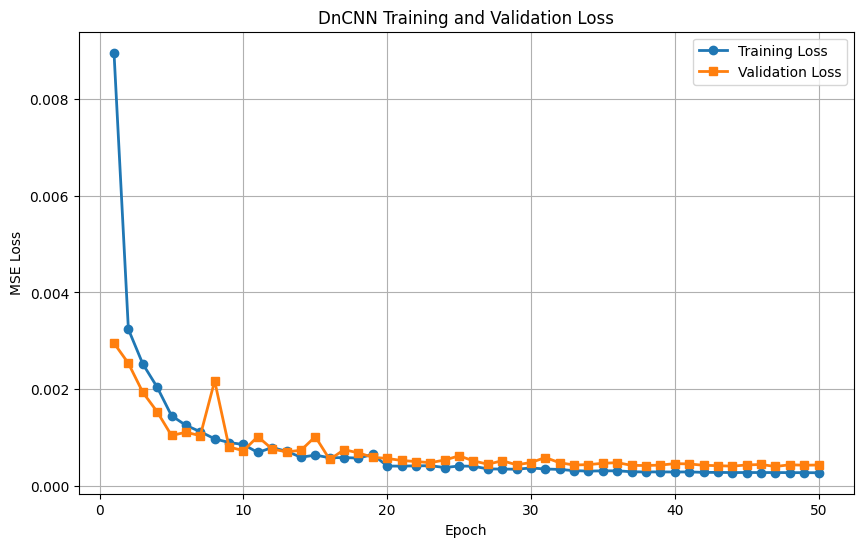

In [154]:
# Create the figure
plt.figure(figsize=(10, 6))

# Plot the training loss
plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

# Plot the validation loss
plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

# Add labels and title
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("DnCNN Training and Validation Loss")

# Display the legend
plt.legend()

# Display grid lines
plt.grid(True)

# Show the figure
plt.show()

**Why this code?**

The graph shows how the model performance changes during training.

It helps identify:

- Learning progress,
- Overfitting,
- Underfitting,
- The point where validation performance stops improving.

**What did we notice?**

Both training and validation loss decreased substantially over the 50 epochs, indicating effective learning.

Validation loss showed some fluctuations, while the learning-rate scheduler progressively reduced the learning rate when improvement slowed.

The lowest validation loss was achieved at epoch 47, at approximately 0.000403.

Training loss continued to decrease gradually until epoch 50, while validation loss remained slightly above its epoch-47 minimum.

The loss curves indicate that the model converged successfully, while checkpointing ensured that the epoch-47 model was retained for final evaluation.


## 5.19. Load the Best Model

In [155]:
# Load the save checkpoint
checkpoint = torch.load(
    best_model_path,
    map_location=device
)

# Restore the best model weights
model.load_state_dict(
    checkpoint["model_state_dict"]
)

# Switch the model to evaluation mode
model.eval()

# Display the selected epoch
print(
    "Loaded model from epoch:",
    checkpoint["epoch"]
)
# Display the best validation loss
print(
    "Best validation loss:",
    checkpoint["validation_loss"]
)

Loaded model from epoch: 47
Best validation loss: 0.00040258391345560085


**Why this code?**

The final test evaluation should use the checkpoint with the lowest validation loss rather than automatically using the last training epoch.


**What did we notice?**

The best checkpoint was obtained at epoch 47, with a validation loss of approximately 0.000403.

Although training continued until epoch 50, the later epochs did not achieve a lower validation loss.

Therefore, the epoch-47 checkpoint was selected for final test-set evaluation.


## 5.20. Import Evaluation Metrics

In [156]:
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

**Why this code?**

These functions are used to calculate PSNR and SSIM.

- PSNR measures reconstruction quality.

- SSIM measures structural similarity between the denoised image and the clean target.

## 5.21. Define the Metric Function

In [157]:
def calculate_metrics(
    clean_image,
    comparison_image
):

    # Calculate Mean Squared Error
    mse = np.mean(
        (
            clean_image
            - comparison_image
        ) ** 2
    )

    # Calculate Peak Signal-to-Noise Ratio
    psnr = peak_signal_noise_ratio(
        clean_image,
        comparison_image,
        data_range=1.0
    )

    # Calculate Structural Similarity Index
    ssim = structural_similarity(
        clean_image,
        comparison_image,
        channel_axis=-1,
        data_range=1.0
    )

    # Return all three metrics
    return mse, psnr, ssim

**Why this code?**

The function calculates three image-quality metrics.

- **MSE**: lower values are better.
- **PSNR**: higher values are better.
- **SSIM**: values closer to 1 are better.

**What did we notice?**

- The function combines three complementary evaluation metrics.

- MSE measures pixel-level reconstruction error, PSNR measures image reconstruction quality, and SSIM measures structural similarity.

- Using multiple metrics provides a more reliable evaluation than relying on a single metric.

## 5.22. Evaluate the Test Set

In [158]:
# Create an empty list for test results
test_results = []

# Switch the model to evaluation mode
model.eval()

# Disable gradient calculations
with torch.no_grad():

    # Process every test batch
    for batch in tqdm(test_loader):

        # Load noisy images and move them to the device
        noisy = batch["noisy"].to(device)

        # Load clean images and move them to the device
        clean = batch["clean"].to(device)

        # Predict the noise residual
        predicted_noise = model(noisy)

        # Reconstruct the denoised image
        denoised = torch.clamp(
            noisy - predicted_noise,
            0,
            1
        )

        # Convert noisy tensors to NumPy arrays
        noisy_np = (
            noisy.cpu()
            .permute(0, 2, 3, 1)
            .numpy()
        )

        # Convert clean tensors to NumPy arrays
        clean_np = (
            clean.cpu()
            .permute(0, 2, 3, 1)
            .numpy()
        )

        # Convert denoised tensors to NumPy arrays
        denoised_np = (
            denoised.cpu()
            .permute(0, 2, 3, 1)
            .numpy()
        )

        # Calculate metrics for every image in the batch
        for index in range(
            noisy_np.shape[0]
        ):

            # Compare noisy input with clean target
            noisy_mse, noisy_psnr, noisy_ssim = (
                calculate_metrics(
                    clean_np[index],
                    noisy_np[index]
                )
            )

            # Compare DnCNN output with clean target
            denoised_mse, denoised_psnr, denoised_ssim = (
                calculate_metrics(
                    clean_np[index],
                    denoised_np[index]
                )
            )

            # Store all evaluation results
            test_results.append({
                "noisy_mse": noisy_mse,
                "noisy_psnr": noisy_psnr,
                "noisy_ssim": noisy_ssim,
                "denoised_mse": denoised_mse,
                "denoised_psnr": denoised_psnr,
                "denoised_ssim": denoised_ssim
            })

  0%|          | 0/26 [00:00<?, ?it/s]

**Why this code?**

The code compares two cases:

- Noisy input against the clean target,
- DnCNN output against the clean target.

This shows whether the model improves image quality.

**What did we notice?**

The trained DnCNN model generated denoised images for every test sample without updating the model weights.

The evaluation results for every image were stored for later statistical analysis and comparison with the original noisy images.

## 5.23. Create Result DataFrame

In [159]:
# Convert the evaluation results into a DataFrame
results_df = pd.DataFrame(test_results)

# Define the output path for the test results
results_path = os.path.join(
    RESULTS_ROOT,
    "dncnn_test_results.csv"
)

# Save the test results as CSV file
results_df.to_csv(
    results_path,
    index=False
)

# Display summary statistics
results_df.describe()

,noisy_mse,noisy_psnr,noisy_ssim,denoised_mse,denoised_psnr,denoised_ssim
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,0.003728,26.850047,0.457769,0.000524,35.537670,0.867222
std,0.004898,4.743961,0.199017,0.000861,4.449473,0.100284
min,0.000154,15.817417,0.093236,0.000051,23.423514,0.564853
25%,0.001049,23.176480,0.345540,0.000136,32.853833,0.838324
50%,0.001931,27.143104,0.448214,0.000248,36.064076,0.893731
75%,0.004812,29.791354,0.560243,0.000518,38.656789,0.945974
max,0.026197,38.132236,0.915291,0.004546,42.934601,0.973555


**Why this code?**

This code converts the list of evaluation results into a Pandas DataFrame.

The DataFrame makes it easier to:

- calculate average metrics,
- compare noisy and denoised images,
- save the evaluation results,
- use the results later in the report and presentation.

**What did we notice?**

The DataFrame contains one row for every evaluated image patch.

Each row stores:

- Noisy MSE
- Noisy PSNR
- Noisy SSIM
- Denoised MSE
- Denoised PSNR
- Denoised SSIM


The evaluation results were successfully organized into a structured table.

This made it easier to calculate average performance metrics, compare noisy and denoised images, and export the results for the report and presentation.

## 5.24. Compare the Average Metrics

In [160]:
# Create a summary table for the average image-quality metrics
comparison_table = pd.DataFrame({

    # Calculate average metrics for the noisy input
    "Noisy Input": [
        results_df["noisy_psnr"].mean(),
        results_df["noisy_ssim"].mean(),
        results_df["noisy_mse"].mean()
    ],

    # Calculate average metrics for the DnCNN output
    "DnCNN Output": [
        results_df["denoised_psnr"].mean(),
        results_df["denoised_ssim"].mean(),
        results_df["denoised_mse"].mean()
    ]
},
index=[
    "PSNR",
    "SSIM",
    "MSE"
])

# Display the comparison table
comparison_table

,Noisy Input,DnCNN Output
PSNR,26.850047,35.537670
SSIM,0.457769,0.867222
MSE,0.003728,0.000524


**Why this code?**

This table compares the average image-quality metrics before and after denoising.

The noisy input and DnCNN output are both compared with the same clean ground-truth images.

A successful denoising model should produce a higher PSNR, a higher SSIM, and a lower MSE.


**What did we notice?**

The DnCNN model improved all three image-quality metrics on the test set.

- Average PSNR increased from 26.85 dB to 35.54 dB, an improvement of approximately 8.69 dB.
- Average SSIM increased from 0.4578 to 0.8672, an improvement of approximately 0.4095.
- Average MSE decreased from 0.003728 to 0.000524, corresponding to an approximate 85.9% reduction in pixel-level reconstruction error.

These results indicate that the trained DnCNN model substantially improved the noisy test images relative to their clean ground-truth targets.


## 5.25. Visualize the Test Results

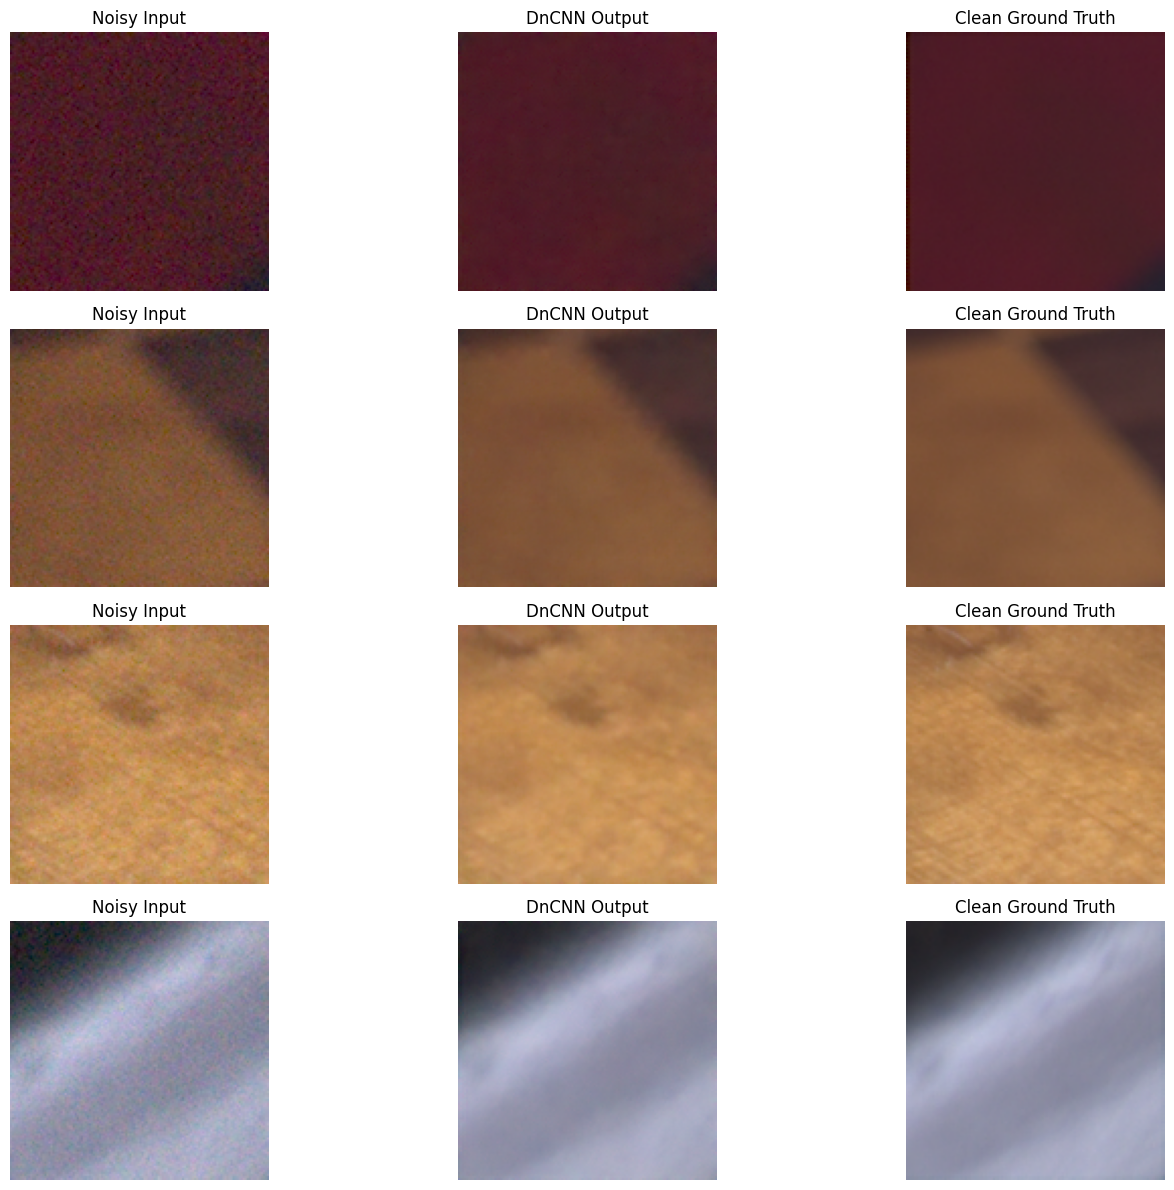

In [161]:
# Load one test batch
batch = next(iter(test_loader))

# Get noisy images
noisy = batch["noisy"].to(device)

# Get clean images
clean = batch["clean"].to(device)

# Disable gradients during prediction
with torch.no_grad():

    # Predict the residual noise
    predicted_noise = model(noisy)

    # Create the denoised image
    denoised = torch.clamp(
        noisy - predicted_noise,
        0,
        1
    )

# Move the images back to the CPU
noisy = noisy.cpu()
clean = clean.cpu()
denoised = denoised.cpu()

# Create the figure
plt.figure(figsize=(15, 12))

# Display up to four examples
number_of_images = min(
    4,
    noisy.shape[0]
)

for index in range(number_of_images):

    # Display the noisy input
    plt.subplot(
        number_of_images,
        3,
        index * 3 + 1
    )

    plt.imshow(
        noisy[index].permute(1, 2, 0)
    )

    plt.title("Noisy Input")
    plt.axis("off")

    # Display the DnCNN output
    plt.subplot(
        number_of_images,
        3,
        index * 3 + 2
    )

    plt.imshow(
        denoised[index].permute(1, 2, 0)
    )

    plt.title("DnCNN Output")
    plt.axis("off")

    # Display the clean target
    plt.subplot(
        number_of_images,
        3,
        index * 3 + 3
    )

    plt.imshow(
        clean[index].permute(1, 2, 0)
    )

    plt.title("Clean Ground Truth")
    plt.axis("off")

# Improve spacing
plt.tight_layout()

# Display the figure
plt.show()

**Why this code?**

Numerical metrics alone do not fully describe visual quality.

The images help us inspect:

- Remaining noise,
- Edge preservation,
- Texture smoothing,
- Color changes,
- Possible artifacts.

**What did we notice?**

Visual inspection complements the numerical evaluation.

The comparison allows us to verify that the model removes visible noise while preserving important image structures such as edges and textures.

Any remaining artifacts or blurred regions can be identified during this stage.

## 5.26. Save the best selected model for final use

In [162]:
# Define the Final Model file path
final_model_path = os.path.join(
    CHECKPOINT_ROOT,
    "dncnn_final_weights.pth"
)

# Save the trained model weights and configuration
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": CONFIG
    },
    final_model_path
)

# Display the Saved Model location
print(
    "Final model saved to:",
    final_model_path
)

Final model saved to: /content/drive/MyDrive/Capstone_Project_Medium/Image_Denoising_Results/checkpoints/dncnn_final_weights.pth


**Why this code?**

The trained model weights and configuration are saved so that the model can be loaded later without retraining.

The saved model can be reused for inference, model comparison, the Streamlit web application, Docker deployment, and the final project demonstration.


**What did we notice?**

The trained model was successfully saved and is now ready for deployment.

The saved model weights will be used in the Streamlit application and later deployed using Docker and Render without requiring retraining.

## 6. Conclusion

This experiment successfully developed and evaluated a DnCNN model for real-image denoising using 128 × 128 image patches. The model uses a 17-layer residual-learning architecture with 128 hidden feature maps and predicts the noise component that is removed from the noisy input to reconstruct the denoised image.

The optimized preprocessing pipeline prepared the image patches before training, reducing repeated full-image loading during each epoch. Profiling showed that one training epoch required approximately 18.69 seconds, consisting of 0.58 seconds for DataLoader waiting, 0.07 seconds for GPU transfer, 6.19 seconds for the forward pass, 10.90 seconds for the backward pass, and 0.95 seconds for the optimizer step. The backward pass was therefore the largest computational component of training.

GPU memory was not a major limitation for this configuration. Peak allocated memory was approximately 567.15 MB, while peak reserved memory was approximately 674 MB on the NVIDIA Tesla T4. This indicates that the model used only a relatively small portion of the available GPU-memory capacity.

The model was trained for the configured maximum of 50 epochs. Training loss decreased from 0.008955 to 0.000274, while the lowest validation loss of approximately 0.000403 was achieved at epoch 47. The learning-rate scheduler progressively reduced the learning rate as validation improvement slowed, and validation-based checkpointing preserved the epoch-47 model for final evaluation.

The final test results showed a substantial improvement after denoising:

- PSNR: 26.85 dB → 35.54 dB, an improvement of approximately 8.69 dB
- SSIM: 0.4578 → 0.8672, an increase of approximately 0.4095
- MSE: 0.003728 → 0.000524, a reduction of approximately 85.9%

Overall, the results demonstrate that DnCNN substantially improved the quality of the noisy test images according to all three evaluation metrics. The experiment also showed that the optimized data pipeline kept data-loading overhead relatively low compared with model computation.  The selected model can later be integrated into the project's  web application and deployment pipeline.